In [1]:
%matplotlib inline

# McCulloch-Pitts Neuron

This was the first neuron

Introduced by Warren McCulloch and Walter Pitts in 1943

<img src="https://1.bp.blogspot.com/-u59IVaKus7U/WhIMOtEpHGI/AAAAAAAAr9Q/S8ChBoRRJtoX8jv6T_fiO7ELmOW4PJWAQCLcBGAs/s400/1.JPG">

We will assume the following notation below

<img src="Images/Fig 2.5.jpg">

 * $v = w^t x + b$
 * $y = \text{hardlim}(v)$

Additional readings if you need/want: 

  * McCulloch-Pitts and Perceptron: http://ecee.colorado.edu/~ecen4831/lectures/NNet2.html
  * Wikipedia: https://en.wikipedia.org/wiki/Perceptron
  * Wordy explanation: https://towardsdatascience.com/mcculloch-pitts-model-5fdf65ac5dd1 and https://towardsdatascience.com/perceptron-learning-algorithm-d5db0deab975
  
First, lets make and plot a two dimensional data set in Python!

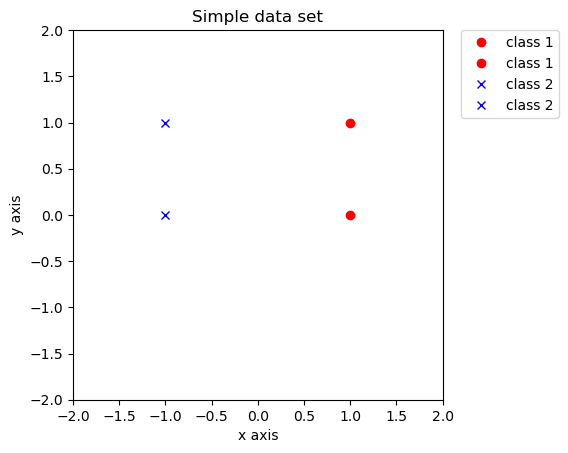

In [2]:
import numpy as np # include the numpy library for operations on arrays as the name "np"
import matplotlib.pyplot as plt # include the plotting library as the name "plt"

# Lets make a really simple "data set"
#  sample 1: (1,1), label == 0 ("class 1")
#  sample 2: (1,0), label == 0 ("class 1")
#  sample 3: (-1,0), label == 1 ("class 2")
#  sample 4: (-1,1), label == 1 ("class 2")
X = np.asarray([[1, 1], [1, 0], [-1, -0], [-1, 1]]) # data points
L = np.asarray([0, 0, 1, 1]) # labels

# Quick way to index the labels (Python command to look for 0's or 1's, return indices)
class1 = np.where( L == 0 )
class2 = np.where( L == 1 )

# plot class 1
plt.plot(X[class1,0],X[class1,1],'ro',label="class 1") # draw red (r) and circle (0)

# plot class 2
plt.plot(X[class2,0],X[class2,1],'bx',label="class 2") # draw blue (b) and an "x" (x)

# figure title and axis labels 
plt.title('Simple data set') 
plt.xlabel('x axis')
plt.ylabel('y axis')

# draw x and y equal spacing
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0)
plt.show()

Note, if you are not familiar with arrays, or at least Python arrays in numpy, you can read

 * https://numpy.org/devdocs/user/quickstart.html

Now, lets code up a McCulloch-Pitts neuron in Python

Does this belong to class 1?
True


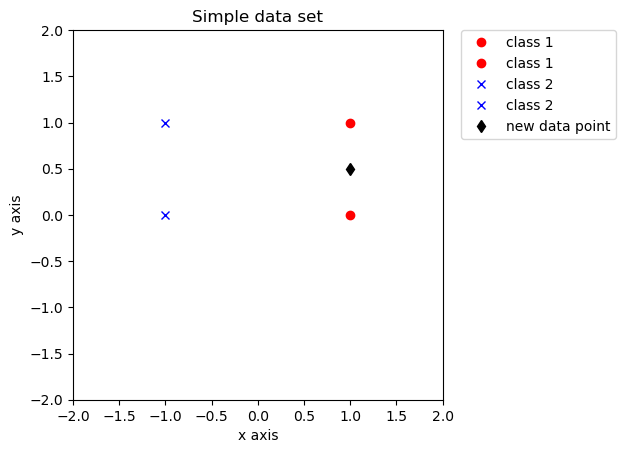

In [3]:
import numpy as np # include the numpy library for ops on arrays as the name "np"

x = np.asarray( [1, 0.5] ) # a new input that we want to run through the neuron

# our weight vector in the McCulloch-Pitts neuron
w = np.asarray( [0.5, 0] ) # we will have to address later how we get/learn/etc. w ...

T = 0 # our threshold for the McCulloch-Pitts neuron

# evaluate our neuron
v = np.dot(x,w) # yup, that simple!
y = ( v > T ) # this is the make a {0,1} decision based on threshold T
print("Does this belong to class 1?")
print(y)

# plot it
plt.plot(X[class1,0],X[class1,1],'ro',label="class 1") # draw red (r) and circle (0)
plt.plot(X[class2,0],X[class2,1],'bx',label="class 2") # draw blue (b) and an "x" (x)
plt.plot(x[0],x[1],'kd',label="new data point")
plt.title('Simple data set') 
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0)
plt.show()

Lets try another data point

Does this belong to class 1?
False


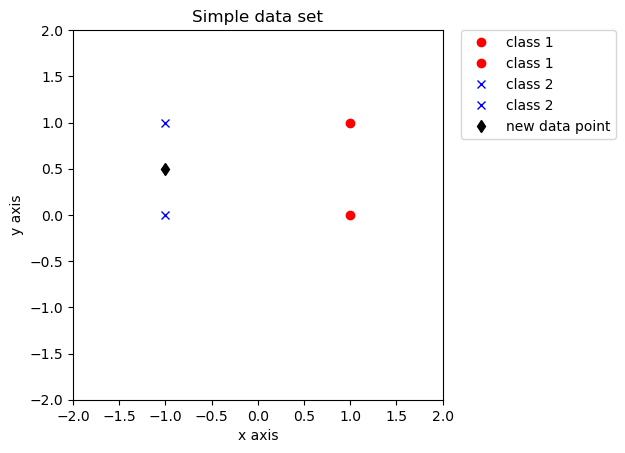

In [4]:
x = np.asarray( [-1, 0.5] ) # a new input

# compute the neuron
v = np.dot(x,w)
y = ( v > T )
print("Does this belong to class 1?")
print(y)

# plot it
plt.plot(X[class1,0],X[class1,1],'ro',label="class 1") # draw red (r) and circle (0)
plt.plot(X[class2,0],X[class2,1],'bx',label="class 2") # draw blue (b) and an "x" (x)
plt.plot(x[0],x[1],'kd',label="new data point")
plt.title('Simple data set') 
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0)
plt.show()

Easy stuff, right?

# Reflection time

Being able to address the following will prepare you for exams, projects, etc. I am not grading these questions, BUT, I do grade exams and projects, read between the lines :-) I will randomly pick questions to answer and can take questions from the class if enough of you are stuck on something.

**Simple**

1) Identify a weight vector that does NOT seperate these two classes

2) What is another weight vector that DOES separate these two classes

3) Can you pick a $T$ that breaks the above?

**Slightly More Challenging**

4) What is the "relationship" between $T$ and $w$?

5) Can you make logic statements like $\text{AND}(x_1,x_2)$ or $\text{OR}(x_1,x_2)$ or $\text{NOR}(x_1,x_2)$ or $\text{AND}(x_1,\text{NOT}(x_2)}$. You can refer to <a href="https://towardsdatascience.com/mcculloch-pitts-model-5fdf65ac5dd1">link</a> if you are stumped